In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow
from tensorflow import keras

In [6]:
df=pd.read_csv("bank-full.csv",sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [8]:
df.shape

(45211, 17)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [9]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [12]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [15]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


job:
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

marital:
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education:
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

default:
default
no     44396
yes      815
Name: count, dtype: int64

housing:
housing
yes    25130
no     20081
Name: count, dtype: int64

loan:
loan
no     37967
yes     7244
Name: count, dtype: int64

contact:
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

month:
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Nam

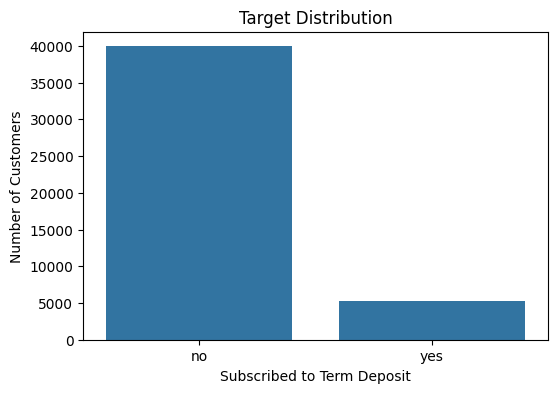

In [16]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="y")

plt.title("Target Distribution")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Number of Customers")

plt.show()

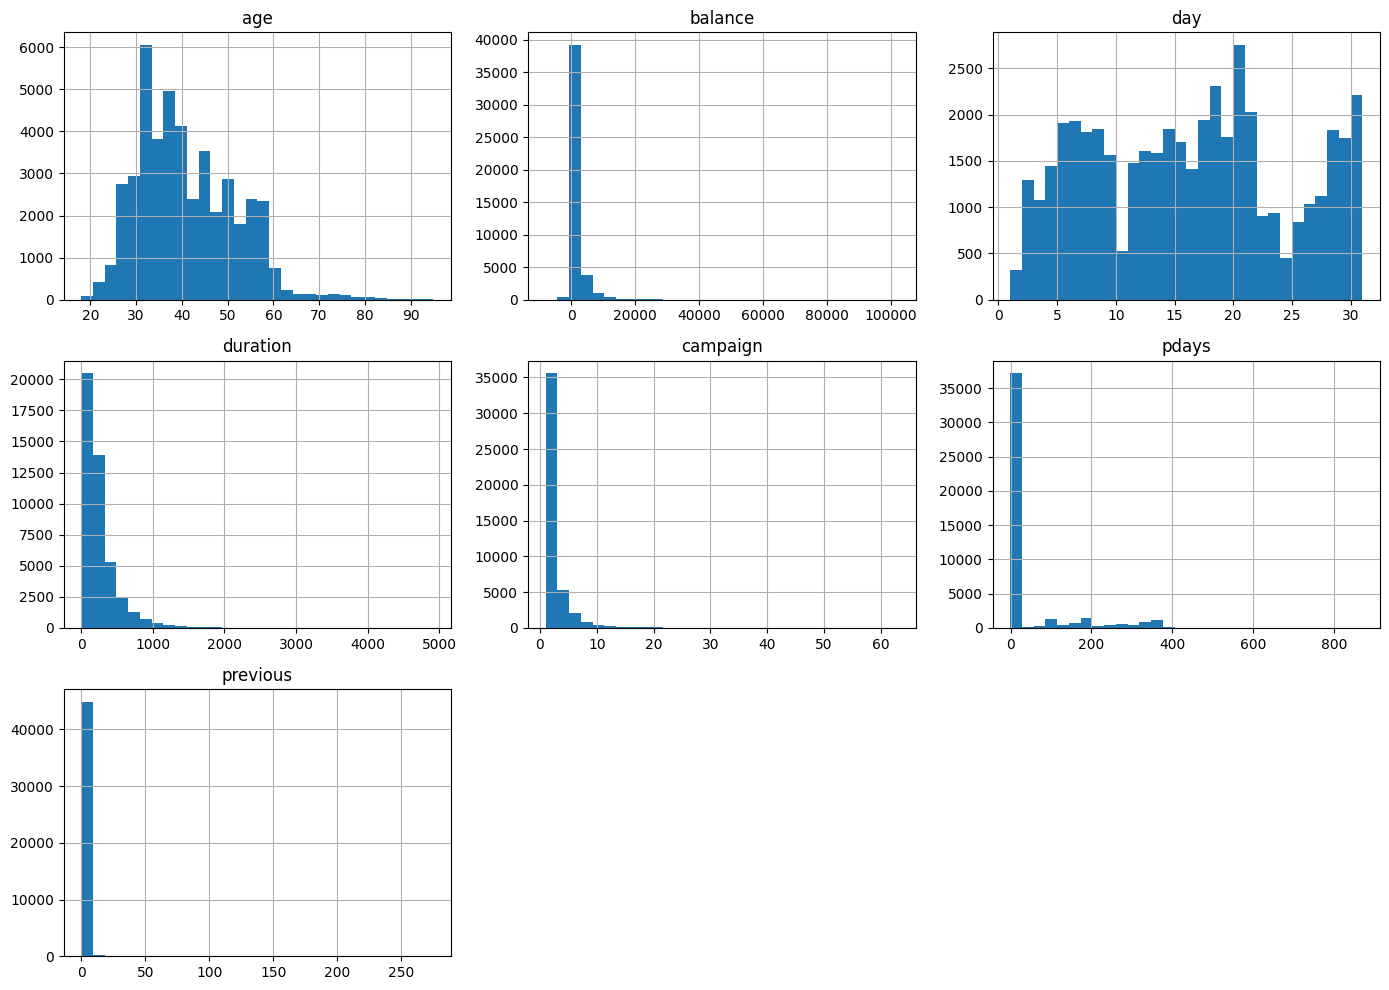

In [17]:
numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

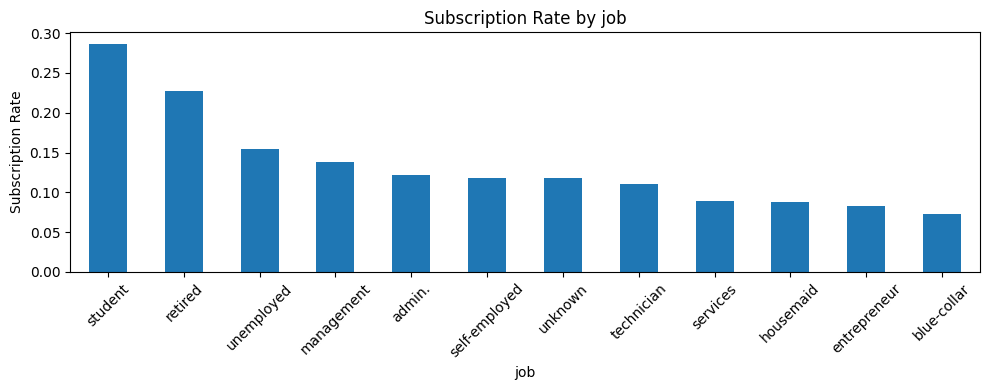

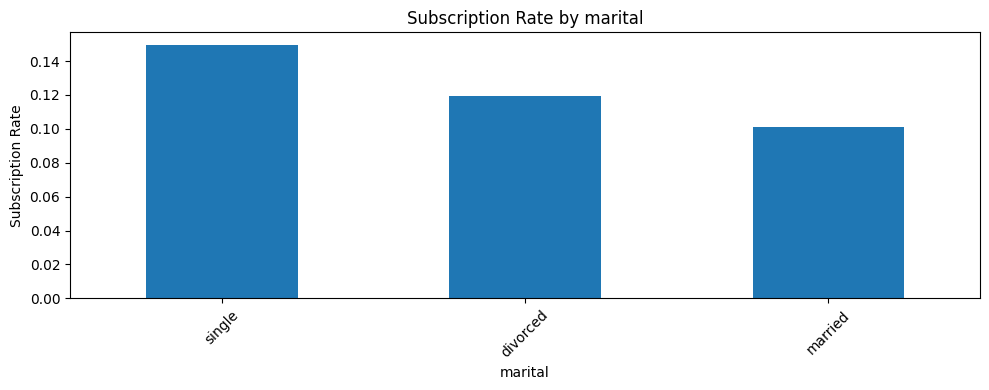

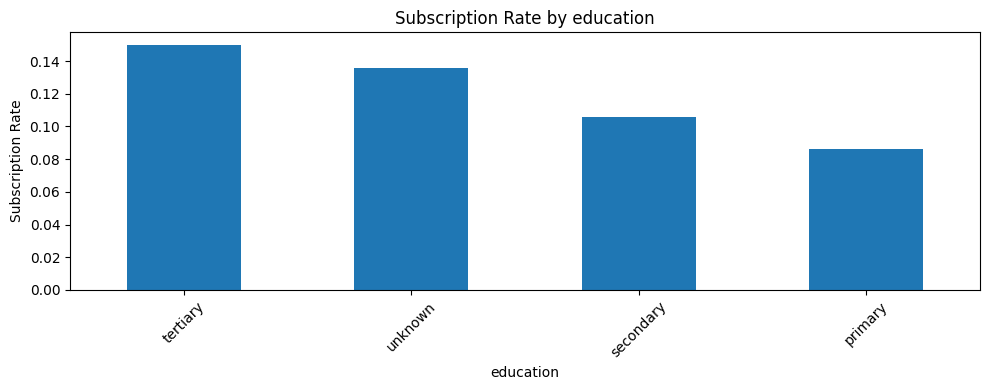

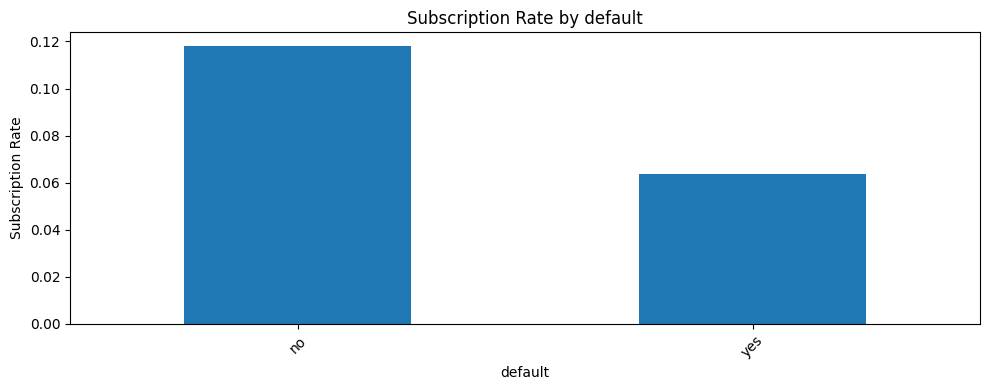

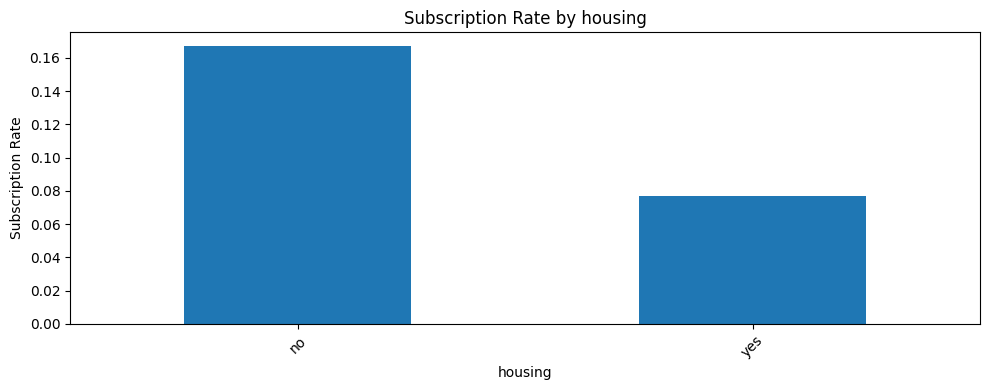

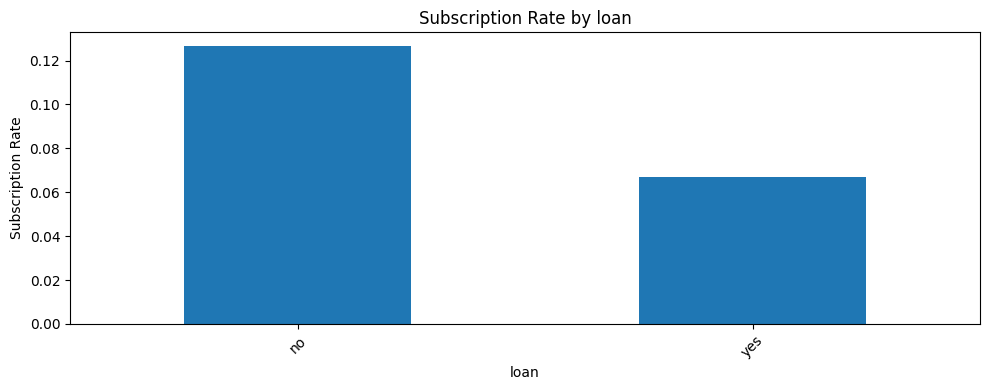

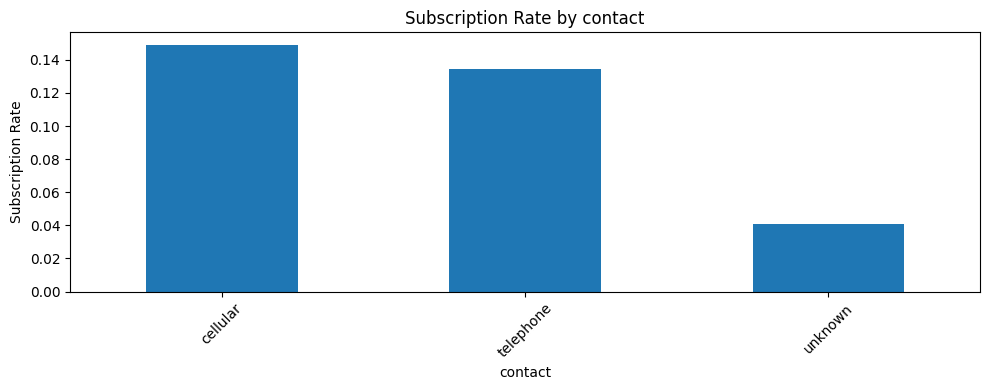

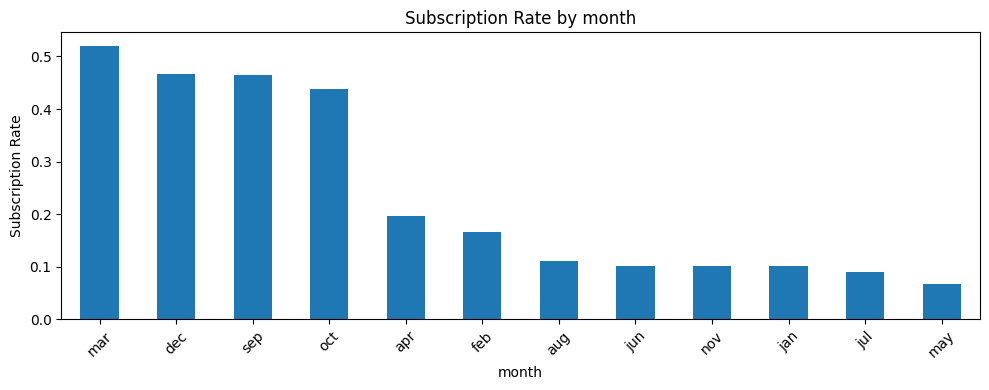

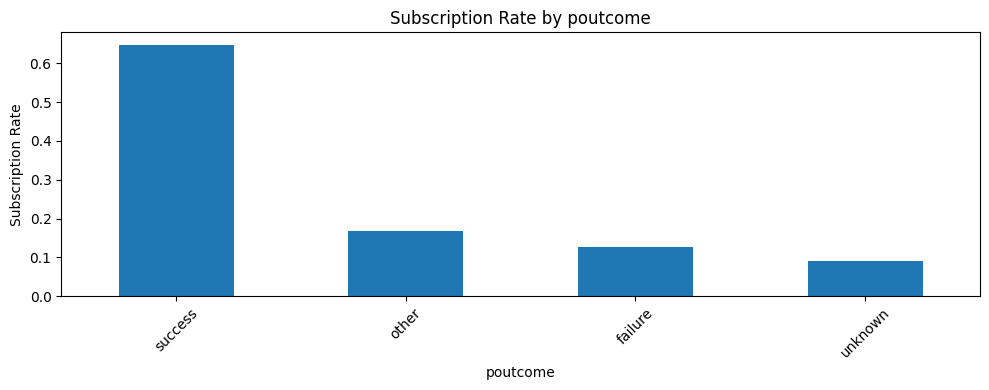

In [18]:
categorical_cols = df.select_dtypes(include="object").columns.drop("y")

for col in categorical_cols:
    rate = df.groupby(col)["y"].apply(lambda x: (x == "yes").mean()).sort_values(ascending=False)

    plt.figure(figsize=(10, 4))
    rate.plot(kind="bar")

    plt.title(f"Subscription Rate by {col}")
    plt.ylabel("Subscription Rate")
    plt.xlabel(col)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [19]:
X = df.drop("y", axis=1)
y = df["y"]

In [20]:
y = y.map({"no": 0,"yes": 1})

In [21]:
X

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown


In [22]:
y

0        0
1        0
2        0
3        0
4        0
        ..
45206    1
45207    1
45208    1
45209    0
45210    0
Name: y, Length: 45211, dtype: int64

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [24]:
X_train.shape

(36168, 16)

In [25]:
X_test.shape

(9043, 16)

In [26]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

In [29]:
print(list(numeric_cols))


['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [30]:
print(list(categorical_cols))

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [32]:
X_train_processed.shape

(36168, 51)

In [36]:
X_train_processed[1]

array([-1.58964093,  0.89962705, -1.2983841 ,  2.5024925 ,  0.39820171,
        1.44609608,  2.6645844 ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
        1.        ,  0.        ,  1.        ,  0.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
        0.        ])

In [37]:
X_test_processed.shape

(9043, 51)

In [38]:
X_test_processed[1]

array([ 0.29237054, -0.32181622,  1.7021447 , -0.21419767, -0.24610373,
       -0.41090988, -0.24150867,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  1.        ,  0.        ,  0.        ,  1.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  1.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        1.        ])

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
lr = LogisticRegression(max_iter=1000)

# Train
lr.fit(X_train_processed, y_train)

# Predict
y_pred_lr = lr.predict(X_test_processed)

# Accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.901249585314608


In [40]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



In [41]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[7782  203]
 [ 690  368]]


In [45]:
from sklearn.pipeline import Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score, classification_report

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 0.9044564856795311
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.65      0.40      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       0.89      0.90      0.89      9043



In [47]:
from keras import Sequential
from keras.layers import Dense

In [50]:
ann = Sequential()

ann.add(Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)))
ann.add(Dense(32, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))

ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


C:\Users\Mitrahang\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
ann.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           3,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
history = ann.fit(
    X_train_processed,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8979 - loss: 0.2406 - val_accuracy: 0.8996 - val_loss: 0.2250
Epoch 2/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9045 - loss: 0.2132 - val_accuracy: 0.9064 - val_loss: 0.2130
Epoch 3/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9065 - loss: 0.2060 - val_accuracy: 0.9081 - val_loss: 0.2043
Epoch 4/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9092 - loss: 0.1995 - val_accuracy: 0.9107 - val_loss: 0.2008
Epoch 5/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9109 - loss: 0.1956 - val_accuracy: 0.9063 - val_loss: 0.2029
Epoch 6/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9115 - loss: 0.1915 - val_accuracy: 0.9108 - val_loss: 0.1986
Epoch 7/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9137 - loss: 0.1887 - val_accuracy: 0.9108 - val_loss: 0.1982
Epoch 8/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9151 - loss: 0.1856 - val_accuracy: 0.

In [54]:
test_loss, ann_accuracy = ann.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

print("ANN Accuracy:", ann_accuracy)

ANN Accuracy: 0.8910759687423706


In [56]:
y_prob_ann = ann.predict(X_test_processed)

y_pred_ann = (y_prob_ann >= 0.5).astype(int).ravel()

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [57]:
print(classification_report(y_test, y_pred_ann))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7985
           1       0.54      0.52      0.53      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.73      0.73      9043
weighted avg       0.89      0.89      0.89      9043



In [58]:
print(confusion_matrix(y_test, y_pred_ann))

[[7512  473]
 [ 512  546]]


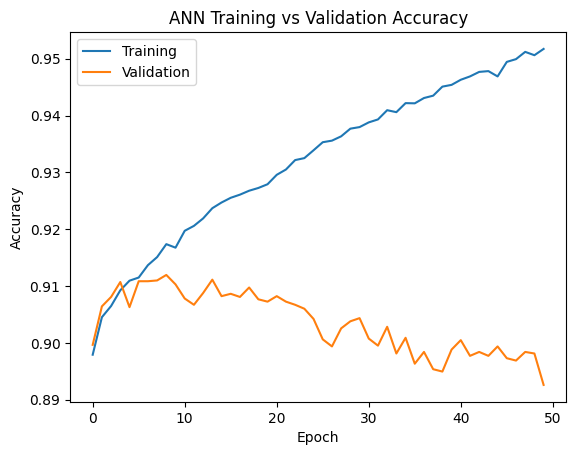

In [59]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ANN Training vs Validation Accuracy')

plt.legend(['Training', 'Validation'])
plt.show()

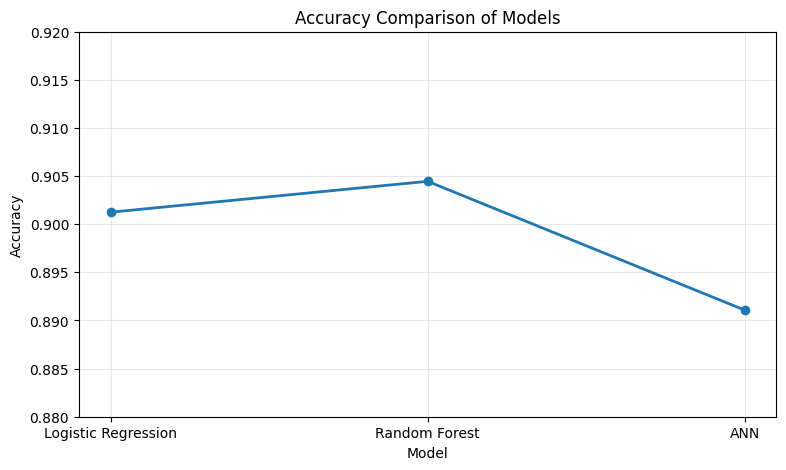

In [60]:
models = ['Logistic Regression', 'Random Forest', 'ANN']
accuracy = [0.901249, 0.904456, 0.891076]

plt.figure(figsize=(9, 5))

plt.plot(models, accuracy, marker='o', linewidth=2)

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Models')

plt.ylim(0.88, 0.92)
plt.grid(True, alpha=0.3)

plt.show()

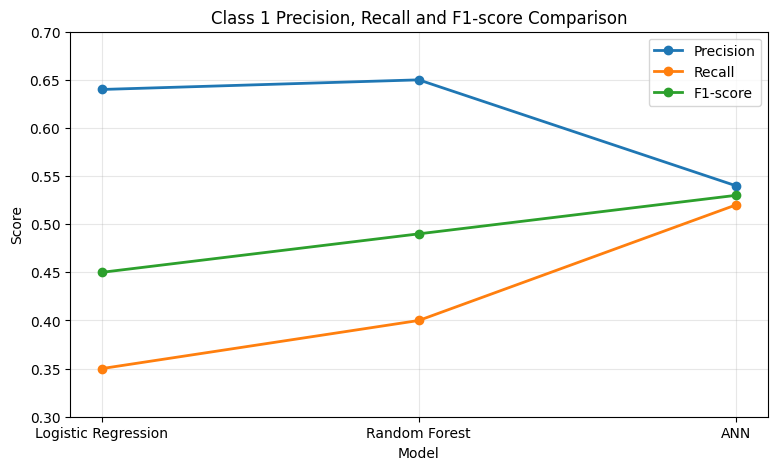

In [61]:

models = ['Logistic Regression', 'Random Forest', 'ANN']

precision = [0.64, 0.65, 0.54]
recall = [0.35, 0.40, 0.52]
f1 = [0.45, 0.49, 0.53]

plt.figure(figsize=(9, 5))

plt.plot(models, precision, marker='o', linewidth=2, label='Precision')
plt.plot(models, recall, marker='o', linewidth=2, label='Recall')
plt.plot(models, f1, marker='o', linewidth=2, label='F1-score')

plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Class 1 Precision, Recall and F1-score Comparison')

plt.ylim(0.3, 0.7)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()